In [8]:
# ============================================
# One-Mode projections from bipartite holdings
#   Input  : final_deduplicated_holdings.csv
#   Expect : (case-insensitive) columns -> manager, stock, ownership (fraction or %)
#   Output : projections_out/*.csv with schema (src, dst, <metric>)
#            - investor_investor_projection.csv         (overlap_count)
#            - investor_investor_jaccard.csv            (jaccard)
#            - investor_investor_cosine.csv             (cosine_weighted)
#            - investor_investor_shared_weight.csv      (shared_weight_sum, proxy = dot product)
#            - firm_firm_projection.csv                 (overlap_count)
#            - firm_firm_jaccard.csv                    (jaccard)
#            - firm_firm_cosine.csv                     (cosine_weighted)
#            - firm_firm_shared_weight.csv              (shared_weight_sum, proxy = dot product)
# ============================================

# ---------------------------- Imports ----------------------------
import os, re
import numpy as np
import pandas as pd

# Prefer sparse for scalability; fall back to dense
try:
    import scipy.sparse as sp
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False

# ---------------------------- Config -----------------------------
INFILE  = "final_deduplicated_holdings.csv"
OUTDIR  = "projections_out"

# Projection thresholds & options
MIN_OVERLAP_COUNT = 2       # keep edges with ≥ this many shared positions
TOPK_PER_NODE     = 50      # keep top-K strongest edges per node (None to disable)
TREAT_OWNERSHIP_AS_PERCENT = True  # auto-convert 0–100 → 0–1 if detected

os.makedirs(OUTDIR, exist_ok=True)

# -------------------------- Helpers --------------------------
def norm_name(s: str) -> str:
    """Normalize entity names: upper, unify symbols, collapse spaces."""
    if not isinstance(s, str):
        s = "" if s is None else str(s)
    s = s.upper().replace("&", " AND ")
    s = re.sub(r"[^\w\s\-\.\&/]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def find_col(df, candidates):
    """Return the first matching column (case-insensitive) or raise."""
    lc = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lc:
            return lc[cand.lower()]
    raise KeyError(f"none of expected columns found among: {candidates}")

def enforce_topk(df_edges, src_col, dst_col, weight_col, k=TOPK_PER_NODE):
    """Symmetric top-K per endpoint to retain the strongest ties."""
    if k is None:
        return df_edges
    top_src = (df_edges.sort_values(weight_col, ascending=False)
                        .groupby(src_col, group_keys=False).head(k))
    top_dst = (df_edges.sort_values(weight_col, ascending=False)
                        .groupby(dst_col, group_keys=False).head(k))
    dfk = pd.concat([top_src, top_dst], ignore_index=True).drop_duplicates([src_col, dst_col])
    return dfk

def to_edges_from_sparse(M, labels, min_val=1e-12):
    """Upper-triangle extraction from a (symmetric) sparse matrix → edge table."""
    coo = M.tocoo()
    mask = (coo.row < coo.col) & (np.abs(coo.data) > min_val)
    i = coo.row[mask]; j = coo.col[mask]; v = coo.data[mask]
    return pd.DataFrame({"src":[labels[idx] for idx in i],
                         "dst":[labels[idx] for idx in j],
                         "value":v})

def mat_to_edges_dense(M, labels, min_val=1e-12):
    """Dense fallback: upper-triangle to edge table."""
    triu = np.triu_indices_from(M, k=1)
    vals = M[triu]
    mask = np.abs(vals) > min_val
    i = triu[0][mask]; j = triu[1][mask]; v = vals[mask]
    return pd.DataFrame({"src":[labels[a] for a in i],
                         "dst":[labels[b] for b in j],
                         "value":v})

# --------------------------- Build ---------------------------
# 1) Load bipartite holdings
df = pd.read_csv(INFILE)

# 2) Map canonical columns
MANAGER = find_col(df, ["manager", "investor", "owner", "holder"])
STOCK   = find_col(df, ["stock", "firm", "issuer", "company"])
OWN     = find_col(df, ["ownership", "weight", "position_weight", "pct_ownership", "stake"])

# 3) Normalize entities and ownership values
df["_manager"] = df[MANAGER].map(norm_name)
df["_stock"]   = df[STOCK].map(norm_name)

own = pd.to_numeric(df[OWN], errors="coerce")
if TREAT_OWNERSHIP_AS_PERCENT and own.notna().any() and own.quantile(0.95) > 1.0:
    own = own / 100.0  # convert 0–100 → 0–1
df["_own"] = own.fillna(0.0).clip(lower=0.0)

# 4) Basic cleaning: drop empties and zero positions
df = df[(df["_manager"] != "") & (df["_stock"] != "")]
df = df[df["_own"] > 0]

# 5) Build incidence matrices (investors × firms), binary & weighted
investors = pd.Index(sorted(df["_manager"].unique()), name="investor")
firms     = pd.Index(sorted(df["_stock"].unique()),   name="firm")

inv_idx  = {n: i for i, n in enumerate(investors)}
firm_idx = {n: i for i, n in enumerate(firms)}

rows = df["_manager"].map(inv_idx).astype(int).to_numpy()
cols = df["_stock"].map(firm_idx).astype(int).to_numpy()

weights = df["_own"].to_numpy()
binary  = np.ones_like(weights, dtype=float)

if HAVE_SCIPY:
    B_w = sp.coo_matrix((weights, (rows, cols)), shape=(len(investors), len(firms))).tocsr()
    B_b = sp.coo_matrix((binary,  (rows, cols)), shape=(len(investors), len(firms))).tocsr()
else:
    B_w = np.zeros((len(investors), len(firms)), dtype=float)
    B_b = np.zeros((len(investors), len(firms)), dtype=float)
    np.add.at(B_w, (rows, cols), weights)
    np.add.at(B_b, (rows, cols), binary)

# ------------------ Investor–Investor projection ------------------
# Metrics:
#   - overlap_count: binary co-holdings (C = B_b @ B_b^T)
#   - jaccard      : intersection / union (binary)
#   - cosine       : cosine similarity on weighted (B_w)
#   - shared_weight_sum (proxy): dot product (B_w @ B_w^T)

if HAVE_SCIPY:
    C_count  = (B_b @ B_b.T).tocsr()
    inv_deg  = np.asarray(B_b.sum(axis=1)).ravel()

    C_weight = (B_w @ B_w.T).tocsr()
    norms    = np.sqrt(np.asarray((B_w.multiply(B_w)).sum(axis=1)).ravel()) + 1e-12
    C_cos    = C_weight.tocoo()
    cos_vals = C_cos.data / (norms[C_cos.row] * norms[C_cos.col])
    C_cos    = sp.coo_matrix((cos_vals, (C_cos.row, C_cos.col)), shape=C_weight.shape).tocsr()

    C_shared = C_weight.copy()  # proxy for shared weight via dot product

    inv_labels    = list(investors)
    df_inv_count  = to_edges_from_sparse(C_count,  inv_labels).rename(columns={"value":"overlap_count"})
    df_inv_count  = df_inv_count[df_inv_count["overlap_count"] >= MIN_OVERLAP_COUNT]

    # ----- SAFE JACCARD (sparse) -----
    coo           = C_count.tocoo()
    inter         = coo.data.astype(float)
    deg_i         = inv_deg[coo.row].astype(float)
    deg_j         = inv_deg[coo.col].astype(float)
    union         = deg_i + deg_j - inter
    jacc          = np.zeros_like(inter, dtype=float)
    np.divide(inter, union, out=jacc, where=(union > 0))

    df_inv_jacc   = pd.DataFrame({
        "src": [inv_labels[i] for i in coo.row],
        "dst": [inv_labels[j] for j in coo.col],
        "jaccard": jacc
    })
    df_inv_jacc   = df_inv_jacc[(df_inv_jacc["src"] < df_inv_jacc["dst"]) & (df_inv_jacc["jaccard"] > 0)]

    df_inv_cos    = to_edges_from_sparse(C_cos,    inv_labels).rename(columns={"value":"cosine_weighted"})
    df_inv_sharedw= to_edges_from_sparse(C_shared, inv_labels).rename(columns={"value":"shared_weight_sum"})
else:
    C_count  = B_b @ B_b.T
    inv_deg  = B_b.sum(axis=1).ravel()
    C_weight = B_w @ B_w.T
    norms    = np.linalg.norm(B_w, axis=1) + 1e-12
    C_cos    = np.divide(C_weight, np.outer(norms, norms), out=np.zeros_like(C_weight), where=np.outer(norms, norms)>0)
    C_shared = C_weight

    inv_labels     = list(investors)
    df_inv_count   = mat_to_edges_dense(C_count,  inv_labels).rename(columns={"value":"overlap_count"})
    df_inv_count   = df_inv_count[df_inv_count["overlap_count"] >= MIN_OVERLAP_COUNT]

    # ----- SAFE JACCARD (dense) -----
    tmp            = mat_to_edges_dense(C_count,  inv_labels, min_val=1e-9).rename(columns={"value":"intersection"})
    deg_map        = dict(zip(inv_labels, inv_deg))
    deg_i          = tmp["src"].map(deg_map).astype(float).to_numpy()
    deg_j          = tmp["dst"].map(deg_map).astype(float).to_numpy()
    inter          = tmp["intersection"].astype(float).to_numpy()
    union          = deg_i + deg_j - inter
    jacc           = np.zeros_like(inter, dtype=float)
    np.divide(inter, union, out=jacc, where=(union > 0))
    tmp["jaccard"] = jacc
    df_inv_jacc    = tmp.loc[tmp["jaccard"] > 0, ["src","dst","jaccard"]]

    df_inv_cos     = mat_to_edges_dense(C_cos,     inv_labels).rename(columns={"value":"cosine_weighted"})
    df_inv_sharedw = mat_to_edges_dense(C_shared,  inv_labels).rename(columns={"value":"shared_weight_sum"})

# optional symmetric top-K trimming
df_inv_count   = enforce_topk(df_inv_count,   "src","dst","overlap_count",     k=TOPK_PER_NODE)
df_inv_jacc    = enforce_topk(df_inv_jacc,    "src","dst","jaccard",           k=TOPK_PER_NODE)
df_inv_cos     = enforce_topk(df_inv_cos,     "src","dst","cosine_weighted",   k=TOPK_PER_NODE)
df_inv_sharedw = enforce_topk(df_inv_sharedw, "src","dst","shared_weight_sum", k=TOPK_PER_NODE)

# save
df_inv_count.to_csv(os.path.join(OUTDIR, "investor_investor_projection.csv"), index=False)
df_inv_jacc.to_csv(os.path.join(OUTDIR,  "investor_investor_jaccard.csv"),    index=False)
df_inv_cos.to_csv(os.path.join(OUTDIR,   "investor_investor_cosine.csv"),      index=False)
df_inv_sharedw.to_csv(os.path.join(OUTDIR,"investor_investor_shared_weight.csv"), index=False)

# --------------------- Firm–Firm projection ---------------------
# Same metrics with roles transposed: firms × investors
if HAVE_SCIPY:
    FB_b     = B_b.T
    FB_w     = B_w.T
    F_count  = (FB_b @ FB_b.T).tocsr()
    firm_deg = np.asarray(FB_b.sum(axis=1)).ravel()

    F_weight = (FB_w @ FB_w.T).tocsr()
    norms_f  = np.sqrt(np.asarray((FB_w.multiply(FB_w)).sum(axis=1)).ravel()) + 1e-12
    F_cos    = F_weight.tocoo()
    fcos_vals= F_cos.data / (norms_f[F_cos.row] * norms_f[F_cos.col])
    F_cos    = sp.coo_matrix((fcos_vals, (F_cos.row, F_cos.col)), shape=F_weight.shape).tocsr()
    F_shared = F_weight.copy()

    firm_labels   = list(firms)
    df_f_count    = to_edges_from_sparse(F_count, firm_labels).rename(columns={"value":"overlap_count"})
    df_f_count    = df_f_count[df_f_count["overlap_count"] >= MIN_OVERLAP_COUNT]

    # ----- SAFE JACCARD (sparse) -----
    coo_f         = F_count.tocoo()
    inter_f       = coo_f.data.astype(float)
    deg_i_f       = firm_deg[coo_f.row].astype(float)
    deg_j_f       = firm_deg[coo_f.col].astype(float)
    union_f       = deg_i_f + deg_j_f - inter_f
    jacc_f        = np.zeros_like(inter_f, dtype=float)
    np.divide(inter_f, union_f, out=jacc_f, where=(union_f > 0))

    df_f_jacc     = pd.DataFrame({
        "src": [firm_labels[i] for i in coo_f.row],
        "dst": [firm_labels[j] for j in coo_f.col],
        "jaccard": jacc_f
    })
    df_f_jacc     = df_f_jacc[(df_f_jacc["src"] < df_f_jacc["dst"]) & (df_f_jacc["jaccard"] > 0)]

    df_f_cos      = to_edges_from_sparse(F_cos,    firm_labels).rename(columns={"value":"cosine_weighted"})
    df_f_shared   = to_edges_from_sparse(F_shared, firm_labels).rename(columns={"value":"shared_weight_sum"})
else:
    FB_b     = B_b.T
    FB_w     = B_w.T
    F_count  = FB_b @ FB_b.T
    firm_deg = FB_b.sum(axis=1).ravel()
    F_weight = FB_w @ FB_w.T
    norms_f  = np.linalg.norm(FB_w, axis=1) + 1e-12
    F_cos    = np.divide(F_weight, np.outer(norms_f, norms_f),
                         out=np.zeros_like(F_weight), where=np.outer(norms_f, norms_f)>0)
    F_shared = F_weight

    firm_labels   = list(firms)
    df_f_count    = mat_to_edges_dense(F_count, firm_labels).rename(columns={"value":"overlap_count"})
    df_f_count    = df_f_count[df_f_count["overlap_count"] >= MIN_OVERLAP_COUNT]

    # ----- SAFE JACCARD (dense) -----
    tmp_f         = mat_to_edges_dense(F_count, firm_labels, min_val=1e-9).rename(columns={"value":"intersection"})
    deg_map_f     = dict(zip(firm_labels, firm_deg))
    deg_i_f       = tmp_f["src"].map(deg_map_f).astype(float).to_numpy()
    deg_j_f       = tmp_f["dst"].map(deg_map_f).astype(float).to_numpy()
    inter_f       = tmp_f["intersection"].astype(float).to_numpy()
    union_f       = deg_i_f + deg_j_f - inter_f
    jacc_f        = np.zeros_like(inter_f, dtype=float)
    np.divide(inter_f, union_f, out=jacc_f, where=(union_f > 0))
    tmp_f["jaccard"] = jacc_f
    df_f_jacc     = tmp_f.loc[tmp_f["jaccard"] > 0, ["src","dst","jaccard"]]

    df_f_cos      = mat_to_edges_dense(F_cos,    firm_labels).rename(columns={"value":"cosine_weighted"})
    df_f_shared   = mat_to_edges_dense(F_shared, firm_labels).rename(columns={"value":"shared_weight_sum"})

# optional symmetric top-K trimming
df_f_count   = enforce_topk(df_f_count,   "src","dst","overlap_count",     k=TOPK_PER_NODE)
df_f_jacc    = enforce_topk(df_f_jacc,    "src","dst","jaccard",           k=TOPK_PER_NODE)
df_f_cos     = enforce_topk(df_f_cos,     "src","dst","cosine_weighted",   k=TOPK_PER_NODE)
df_f_shared  = enforce_topk(df_f_shared,  "src","dst","shared_weight_sum", k=TOPK_PER_NODE)

# save
df_f_count.to_csv(os.path.join(OUTDIR, "firm_firm_projection.csv"), index=False)
df_f_jacc.to_csv(os.path.join(OUTDIR,  "firm_firm_jaccard.csv"),    index=False)
df_f_cos.to_csv(os.path.join(OUTDIR,   "firm_firm_cosine.csv"),      index=False)
df_f_shared.to_csv(os.path.join(OUTDIR,"firm_firm_shared_weight.csv"), index=False)

print("✓ projections saved to:", OUTDIR)


✓ projections saved to: projections_out


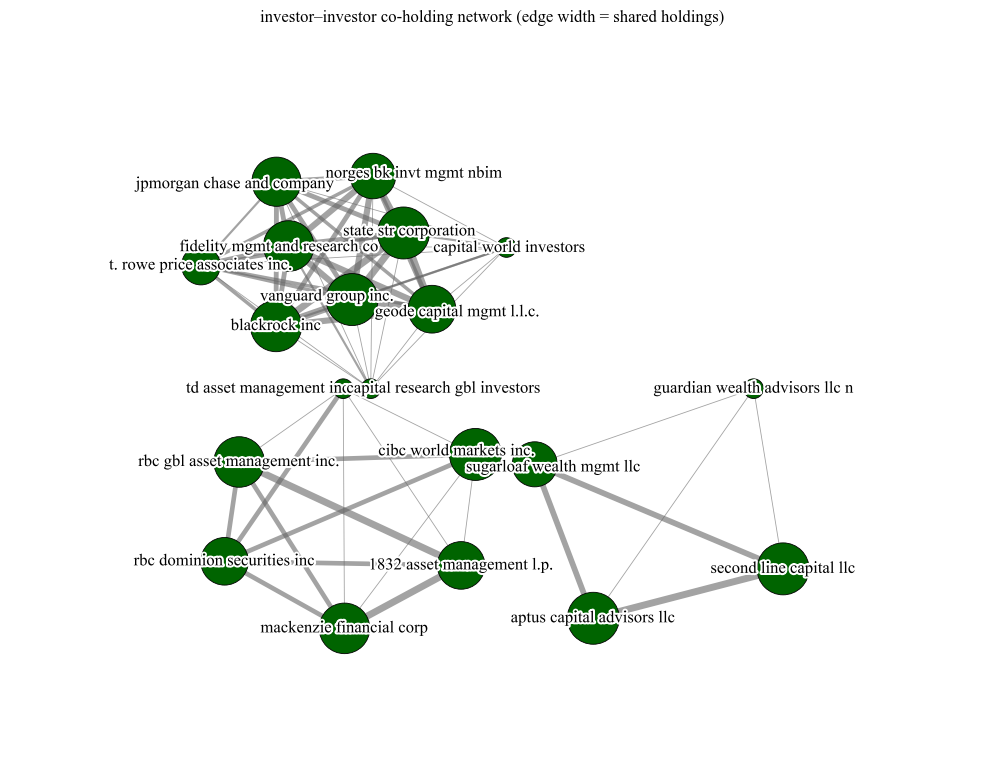

saved: figs/investor_projection_overlap_count_top20.png
       figs/investor_projection_overlap_count_top20.svg


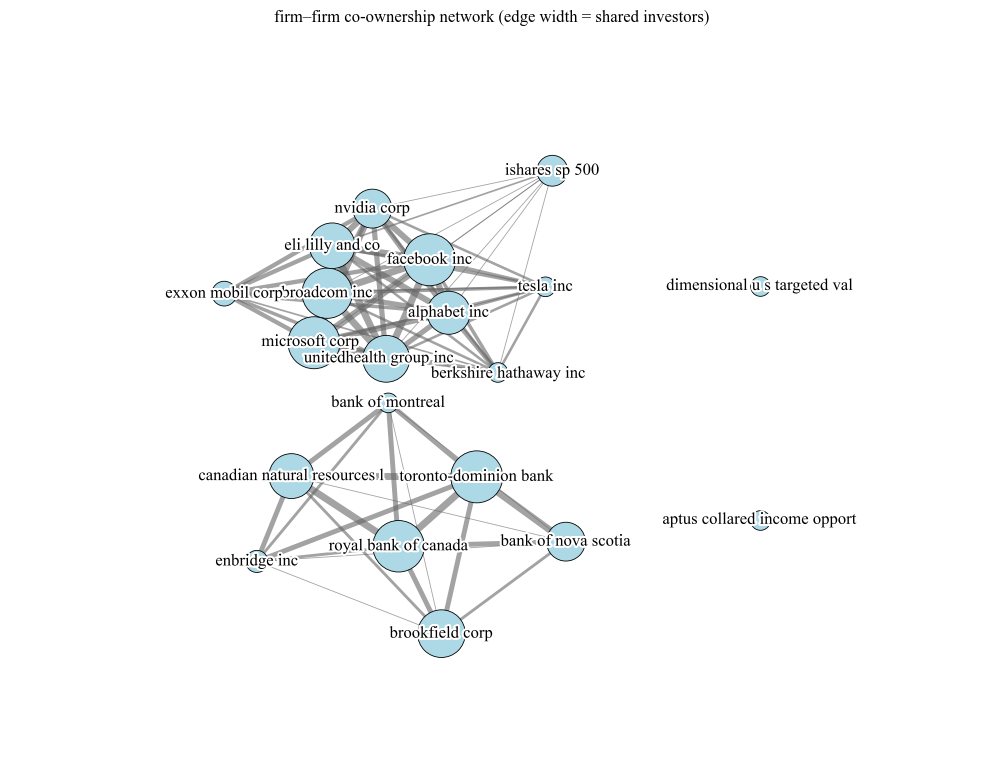

saved: figs/firm_projection_overlap_count_top20.png
       figs/firm_projection_overlap_count_top20.svg


In [9]:
# ============================================
# One-Mode Projection visual

# Purpose: to plot investor–investor and firm–firm one-mode projections with clean, publication-ready styling
#     • Labels: lower-case, Times New Roman 12, white halo
#     • Investors: green nodes
#     • Firms: light-blue nodes
#     • Simple label-repulsion to reduce overlaps

# Inputs:
#   projections_out/investor_investor_projection.csv
#   projections_out/firm_firm_projection.csv

# Outputs:
#   figs/investor_projection_overlap_count_top20.(png|svg)
#   figs/firm_projection_overlap_count_top20.(png|svg)
# ============================================

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe
from pathlib import Path
from math import ceil, sqrt

# ----------------------------- Style -----------------------------
# Use Times New Roman, 12pt everywhere. All label text is set to lower-case later.
mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ------------------------ Utility functions -----------------------
def _robust_scale(arr, lo_hi):
    """
    Map values to [lo, hi] with percentile-based scaling for stability.
    Avoids oversized nodes/edges due to outliers.
    """
    arr = np.asarray(arr, dtype=float)
    if arr.size == 0:
        return np.array([])
    p10, p90 = np.percentile(arr, [10, 90])
    span = (p90 - p10) if p90 > p10 else (arr.max() if arr.max() > 0 else 1.0)
    z = np.clip((arr - p10) / span, 0, 1)
    lo, hi = lo_hi
    return lo + (hi - lo) * z

def _repel_labels(ax, texts, n_iter=80, step=0.02, expand=(1.08, 1.15)):
    """
    Lightweight label repulsion: if two label bounding boxes overlap,
    push them apart slightly in data coordinates.
    Keeps figures readable without changing font size or hiding labels.
    """
    if not texts:
        return
    fig = ax.figure
    for _ in range(n_iter):
        moved = False
        renderer = fig.canvas.get_renderer()
        bbs = [t.get_window_extent(renderer=renderer).expanded(*expand) for t in texts]
        for i in range(len(texts)):
            for j in range(i + 1, len(texts)):
                if bbs[i].overlaps(bbs[j]):
                    xi, yi = texts[i].get_position()
                    xj, yj = texts[j].get_position()
                    dx, dy = (xi - xj), (yi - yj)
                    if dx == 0 and dy == 0:
                        dx = 1e-3
                    norm = (dx * dx + dy * dy) ** 0.5
                    ux, uy = dx / norm, dy / norm
                    texts[i].set_position((xi + ux * step, yi + uy * step))
                    texts[j].set_position((xj - ux * step, yj - uy * step))
                    moved = True
        if not moved:
            break
        fig.canvas.draw_idle()

# ------------------------- Main plotting function -----------------------
def plot_projection_network(
    df_edges: pd.DataFrame,
    *,
    weight_col: str = "overlap_count",
    top_n_nodes: int = 20,
    label_top_k: int | None = None,   # None => label all nodes
    title: str = "",
    outfile_prefix: str = "projection",
    node_color: str = "#006400",      # default: investor dark-green
    component_spacing: float = 2.0,   # spacing between components in the grid
    repel_scale: float = 1.8,         # spring_layout repulsion (higher = more spread)
    node_size_minmax=(200, 1400),
    edge_width_minmax=(0.6, 5.0),
    reduce_overlap: bool = True,      # run label-repulsion pass
):
    """
    Plot a one-mode projection network (undirected, weighted).
    Assumes df_edges contains 'src', 'dst', and the specified weight_col.
    """

    # ---- Validate minimal schema (explicit to avoid guessing mistakes) ----
    required = {"src", "dst", weight_col}
    if not required.issubset(df_edges.columns):
        raise ValueError(f"df_edges must contain columns: {sorted(required)}")

    # ---- Build a simple undirected weighted graph ----
    G = nx.Graph()
    for _, r in df_edges.iterrows():
        u, v, w = r["src"], r["dst"], float(r[weight_col])
        if u == v or w <= 0:
            continue
        if G.has_edge(u, v):
            G[u][v]["weight"] += w
        else:
            G.add_edge(u, v, weight=w)
    if G.number_of_edges() == 0:
        raise ValueError("No edges to plot (after filtering/self-loop removal).")

    # ---- Node strength (weighted degree) and top-N selection ----
    strength = {n: sum(d["weight"] for _, _, d in G.edges(n, data=True)) for n in G.nodes()}
    top_nodes = [n for n, _ in sorted(strength.items(), key=lambda kv: kv[1], reverse=True)[:top_n_nodes]]
    H = G.subgraph(top_nodes).copy()
    for n in H.nodes():
        H.nodes[n]["strength"] = strength[n]

    # ---- Layout: place connected components on a neat grid ----
    comps = [H.subgraph(c).copy() for c in nx.connected_components(H)]
    cols = int(ceil(sqrt(len(comps)))) or 1
    rows = int(ceil(len(comps) / cols))
    grid_centres = [(c, r) for r in range(rows) for c in range(cols)][:len(comps)]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.axis("off")

    pos_all = {}
    for (cx, cy), C in zip(grid_centres, comps):
        nC = C.number_of_nodes()
        k = repel_scale / np.sqrt(max(nC, 2))               # slightly stronger spread for dense components
        pos = nx.spring_layout(C, seed=42, k=k, iterations=300)
        for u in C.nodes():                                  # shift component into its grid cell
            pos[u][0] += cx * component_spacing
            pos[u][1] += cy * component_spacing
        pos_all.update(pos)

        sizes = _robust_scale([C.nodes[u]["strength"] for u in C.nodes()], node_size_minmax)
        eweights = np.array([d["weight"] for _, _, d in C.edges(data=True)], float)
        widths = _robust_scale(eweights, edge_width_minmax) if eweights.size else np.array([])

        nx.draw_networkx_edges(C, pos, width=list(widths), alpha=0.6, edge_color="#666666", ax=ax)
        nodes = nx.draw_networkx_nodes(C, pos, node_color=node_color, node_size=list(sizes), ax=ax)
        nodes.set_edgecolor("black")
        nodes.set_linewidth(0.6)

    # ---- Labels: lower-case + white halo (readable on any background) ----
    if label_top_k is None or label_top_k >= H.number_of_nodes():
        to_label = list(H.nodes())
    else:
        to_label = [n for n, _ in sorted(H.nodes(data="strength"), key=lambda t: t[1], reverse=True)[:label_top_k]]

    halo = [pe.Stroke(linewidth=3, foreground="white"), pe.Normal()]
    texts = []
    for n in to_label:
        x, y = pos_all[n]
        t = ax.text(x, y, str(n).lower(), fontsize=12, ha="center", va="center", color="black")
        t.set_path_effects(halo)
        texts.append(t)

    # Optional label repulsion preserving font/size
    if reduce_overlap:
        fig.canvas.draw()  # ensure text bounding boxes are available
        _repel_labels(ax, texts, n_iter=80, step=0.02, expand=(1.08, 1.15))

    # Lower-case title (consistent with label styling)
    if title:
        ax.set_title(title.lower(), pad=6)

    # Expand bounds so labels aren’t clipped at the frame edge
    xs, ys = zip(*pos_all.values())
    pad = component_spacing * 0.6
    ax.set_xlim(min(xs) - pad, max(xs) + pad)
    ax.set_ylim(min(ys) - pad, max(ys) + pad)

    # Save in both PNG (publication-ready raster) and SVG (vector)
    outdir = Path("figs"); outdir.mkdir(exist_ok=True)
    png = outdir / f"{outfile_prefix}_{weight_col}_top{top_n_nodes}.png"
    svg = outdir / f"{outfile_prefix}_{weight_col}_top{top_n_nodes}.svg"
    plt.tight_layout()
    plt.savefig(png, dpi=300, bbox_inches="tight")
    plt.savefig(svg, bbox_inches="tight")
    plt.show()
    print(f"saved: {png}\n       {svg}")

# ------------------------------ Run both plots ------------------------------
INV_CSV  = "projections_out/investor_investor_projection.csv"  # cols: src,dst,overlap_count
FIRM_CSV = "projections_out/firm_firm_projection.csv"          # cols: src,dst,overlap_count

inv_inv  = pd.read_csv(INV_CSV)
firm_ff  = pd.read_csv(FIRM_CSV)

# Investors (dark green)
plot_projection_network(
    inv_inv,
    weight_col="overlap_count",
    top_n_nodes=20,
    label_top_k=None,  # label all nodes
    title="investor–investor co-holding network (edge width = shared holdings)",
    outfile_prefix="investor_projection",
    node_color="#006400",  # dark green
    reduce_overlap=True
)

# Firms (light blue)
plot_projection_network(
    firm_ff,
    weight_col="overlap_count",
    top_n_nodes=20,
    label_top_k=None,  # label all nodes
    title="firm–firm co-ownership network (edge width = shared investors)",
    outfile_prefix="firm_projection",
    node_color="#ADD8E6",  # light blue
    reduce_overlap=True
)
